# Numerical Methods for Polynomial Interpolation #

$Author$: Michael Simons

$Class$: MTH 437 - Numerical Analysis

$Date$: 11/30/23

## Introduction ##


This report will demonstrate practical application and understanding of monic polynomials, Newton's divided differences, and polynomial interpolation. These concepts serve as essential tools in approximating functions based on data.

## Part 1: Monic Polynomial Incrementation ##

The development of an understanding of monic polynomial behavior is crucial in assessing point-wise error $f(x) - p_{n}(x)$ when approximating functions based on observed data. This section will aim to encapsulate a monic polynomial as an incremental python function, which will be utilized in further sections. The monic polynomial is defined as follows:

$w_{n+1}(x) := (x-x_{0})(x-x_{1})···(x-x_{n})$.

In [8]:
#Compute the value of w_(n+1) given a list of nodes and a value x.
def w_increment(n_points,x_value):
    initial=1 #Set initial value of w_n+1
    for pt in n_points:
        point_contribution=(x_value-pt) #Compute point contribution of each point
        initial=initial*point_contribution #Accumulate answer by applying each contribution
    return initial #Return w_n+1

The above python function successfully captures the definition, and is capable of computing $w_{n+1}$ given the list of $n$ points and an input value $x$.

## Part 2: Chebyshev Nodes and Visualization ##

This section will apply the previously defined monic polynomial structure through visualization. First, $11$ equally distributed nodes within the interval $[-1,1]$ will be computed. The w_increment function will then be used to compute the corresponding values of $w_{11}(x)$ based on the equally distributed nodes. Additionally, 11 zeros of the Chebyshev polynomial will be computed and the w_increment function will compute corresponding values of $w_{11}(x)$ given by the zeros. The zeros of $T_{n+1}$ are given by the following formula:

$x_{j} = cos(\frac{2j+1}{2n+2}\pi)$, where $j = 0,1· · ·n$.

In [9]:
import numpy as np

#Generate more points within the interval for a smoother plot
points_to_plot=100
x_vals=np.linspace(-1,1,points_to_plot)

eq_spaced_nodes=np.linspace(-1, 1, 11) #Produce a list of 11 equally spaced nodes in the interval [-1,1]
w_eq_spaced=[w_increment(eq_spaced_nodes,x) for x in x_vals] #Produce w_11(x) for based on equally spaced

#Produce a list of 11 chebyshev zeros
chebyshev_nodes=np.cos((2 * np.arange(1, 11 + 1) - 1) * np.pi / (2 * 11))
w_chebyshev = [w_increment(chebyshev_nodes,x) for x in x_vals] #Compute w_11(x) based on cheb. zeros

A visualization of $w_{11}(x)$ will now be produced based on each of the computed node sets.

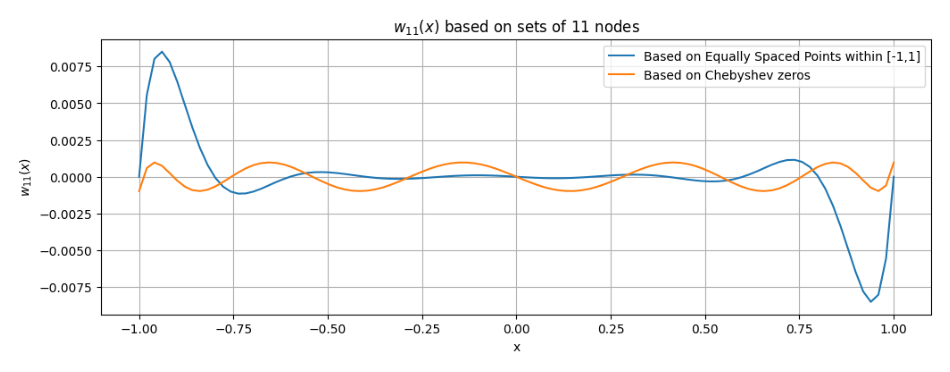

In [14]:
#Plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(x_vals, w_eq_spaced, label='Based on Equally Spaced Points within [-1,1]')
plt.plot(x_vals, w_chebyshev, label='Based on Chebyshev zeros')
plt.xlabel('x')
plt.ylabel('w_{11}(x) based on sets of 11 nodes')
plt.title(f'w_{11}(x)')
plt.legend()
plt.grid(True)
plt.show()

## Part 3: Newton's Divided Differences ##

Newton's divided differences is a method used for polynomial interpolation based on some given data points. The method consists of construction of a divided differences table which determines coefficients of an interpolated function. A python function will now be implemented to find newton's divided differences based on the data points $(x_{0},y_{0}),(x_{1},y_{1}),···,(x_{n},y_{n})$.

In [4]:
import numpy as np
def newtons_divided_differences(x, y):
    n=len(x) #Determine dimenson n
    m=np.zeros((n, n)) #Initialize nxn divided diferences matrix
    m[:, 0]=y #Set the first column of matrix x to the y vector
    for j in range(1,n): #Iterate past 0th elment
        for i in range(n-j): #Obtain index of rows up to (n-j)
            #Apply f[x0,x1,...,xi]=(f[x1,x2,...,xi]-f[x0,x1,...,xi-1])/(xi-x0) to matrix m
            m[i,j]=(m[i+1,j-1]-m[i,j-1])/(x[i+j]-x[i])
    return m[0,:] #Return first row of divided differences matrix

## Part 4: Visualization of Interpolated Polynomials ##

This section will aim to crete two interpolation polynomials for the function $f(x) = \frac{1}{1+12x^{2}}$ based on 11 points distributed evenly in $[-1,1]$ aswell as the 11 zeros of the Chebyshev polynomial. First, $f(x)$ will be encapsulated by a python function.

In [5]:
def f(x): return 1/(1+12*(x**2)) #Define the fixed function f(x)

The points for each of the two interpolation polynomials will now be computed. A third polynomial using $10,000$ points will also be computed to simulate the true $f(x)$. This will allow for visual comparison.

In [6]:
x_eq_spaced=np.linspace(-1, 1, 11) #Obtain 11 equally spaced x values between -1 and 1
y_eq_spaced=f(x_eq_spaced) #Apply f to obtain y values

x_chebyshev=np.cos((2*np.arange(1,10+2)-1)*np.pi/(2*(10+1))) #Obtain cheb. zeros
y_chebyshev=f(x_chebyshev) #Apply f to obtain y values

x_vals=np.linspace(-1,1,10000) #Obtain 10000 equally spaced nodes to model f(x)
y_vals=f(x_vals) #Apply f to obtain y values

A visualization will now be produced to show the two polynomials alongside $f(x)$.

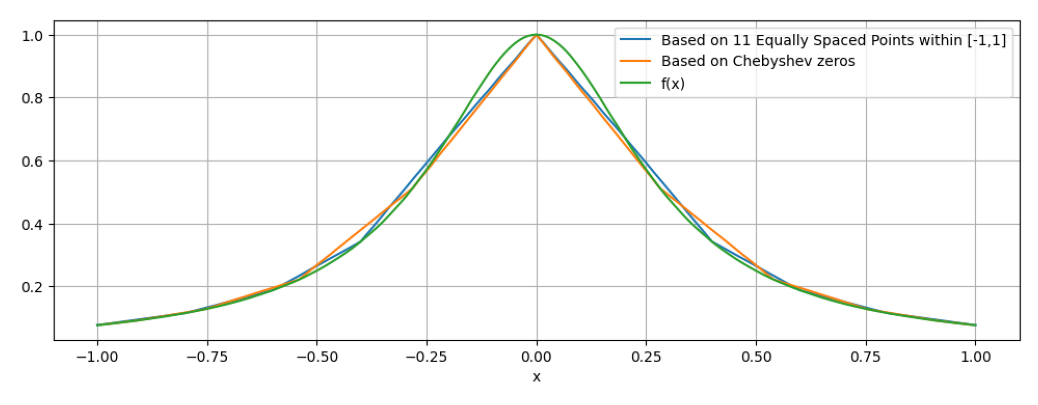

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(x_eq_spaced, y_eq_spaced, label='Based on 11 Equally Spaced Points within [-1,1]')
plt.plot(x_chebyshev, y_chebyshev, label='Based on Chebyshev zeros')
plt.plot(x_vals,y_vals, label='f(x)')
plt.xlabel('x')
plt.legend()
plt.grid(True)
plt.show()

Observably, both of the interpolation polynomials are quite accurate in comparison to the true $f(x)$, despite only being based on 11 equally spaced points.

## Conclusion ##

Through Python implementations and visualizations, this report demonstrated the effectiveness of interpolation methods in approximating functions based on observed data, highlighting the accuracy achieved even with a limited number of data points.